# Upgraded analysis: does WASP improve efficiency?

The original notebook mostly tested "does WASP reduce total CO₂?".
That can be misleading because totals depend heavily on:
- ship size
- hours at sea
- distance traveled

This upgraded notebook adds:
1) Efficiency metrics:
   - distance_nm (implied distance, derived from fuel and fuel_per_nm)
   - CO2_per_nm (CO₂ intensity per nautical mile)
   - fuel_per_nm (already in data)
   - CO2_per_hour (operational intensity)
2) Proper statistical tests (t-test + Mann-Whitney)
3) Ship-type comparisons (only where both WASP and non-WASP exist)
4) Better regressions:
   - robust standard errors (HC3)
   - ship-type fixed effects (C(ship_type))
5) Optional matching (nearest neighbors) for a more causal-ish comparison


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats

df_raw = pd.read_excel("ships_comparisons.xlsx", sheet_name="Sheet1")
df_raw.columns = df_raw.columns.str.strip()

rename_map = {
    "Total CO₂ emissions [m tonnes]": "co2",
    "Total fuel consumption [m tonnes]": "fuel",
    "Time spent at sea [hours]": "hours",
    "Fuel consumption per distance [kg / n mile]": "fuel_per_nm",
    "Length": "length",
    "GT": "GT",
    "Ship type": "ship_type",
    "Reporting Period": "reporting_period",
    "IMO Number": "imo",
    "Name": "name",
    "WASP": "wasp",
}

df = df_raw.rename(columns=rename_map)

keep = ["imo","name","ship_type","reporting_period","wasp","co2","fuel","hours","fuel_per_nm","DWT","GT","length"]
df = df[keep].copy()

num_cols = ["wasp","co2","fuel","hours","fuel_per_nm","DWT","GT","length"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["co2","fuel","hours","fuel_per_nm"]:
    df.loc[df[c] == 0, c] = np.nan

df = df.dropna(subset=["wasp","co2","fuel","hours","fuel_per_nm","DWT","GT","length"]).copy()
df["wasp"] = df["wasp"].astype(int)

df.head()


,imo,name,ship_type,reporting_period,wasp,co2,fuel,hours,fuel_per_nm,DWT,GT,length
2,9512331,NBA MAGRITTE,Bulk carrier,2024,1,4762.31300,1514.9000,2246.20,86.54,82099,43013,229
3,9798856,PYXIS OCEAN,Bulk carrier,2024,1,2538.81170,811.9700,894.50,78.38,80962,43291,229
4,9743758,CHEMICAL CHALLENGER,Chemical tanker,2024,1,6737.78047,2148.2601,3639.70,52.44,16111,9155,134
5,9631345,ANNA,General cargo ship,2024,1,4498.67648,1434.1000,3505.88,39.84,5079,2993,90
6,7633375,SUNNANVIK,Other ship types,2024,1,1999.74250,623.7500,927.51,66.34,9060,7454,124


In [15]:
df["fuel_kg"] = df["fuel"] * 1000
df["distance_nm"] = df["fuel_kg"] / df["fuel_per_nm"]

df.loc[(df["distance_nm"] <= 0) | (~np.isfinite(df["distance_nm"])), "distance_nm"] = np.nan

df["co2_per_nm"] = df["co2"] / df["distance_nm"]
df["co2_per_hour"] = df["co2"] / df["hours"]
df["co2_per_fuel"] = df["co2"] / df["fuel"]

df_eff = df.dropna(subset=["distance_nm","co2_per_nm","co2_per_hour","co2_per_fuel"]).copy()

df_eff[["co2","fuel","hours","fuel_per_nm","distance_nm","co2_per_nm","co2_per_hour","co2_per_fuel","wasp"]].describe()


,co2,fuel,hours,fuel_per_nm,distance_nm,co2_per_nm,co2_per_hour,co2_per_fuel,wasp
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,15082.589884,4799.160005,3916.871000,86.941000,50364.988813,0.273792,3.864630,3.152353,0.475000
std,13554.620707,4332.064359,2078.635451,41.525347,29011.803076,0.130148,2.857756,0.031530,0.505736
min,791.791100,251.850000,375.100000,35.410000,4300.717213,0.112019,1.098870,3.116746,0.000000
25%,5125.897950,1616.850000,2200.582500,61.597500,27323.420258,0.193615,2.147066,3.127915,0.000000
50%,8428.715400,2660.300000,3998.300000,80.690000,45336.346802,0.253875,3.145992,3.139730,0.000000
75%,23891.643815,7660.277500,5639.755000,95.260000,78902.451619,0.297094,4.230889,3.172511,1.000000
max,60655.702320,19412.840000,7275.900000,247.950000,99595.994544,0.774723,13.469139,3.206000,1.000000


### Construction and summary of efficiency metrics

This cell constructs distance- and intensity-based efficiency metrics to move beyond total emissions:

- **distance_nm** estimates distance traveled using fuel consumption and fuel-per-distance data.
- **CO₂ per nautical mile (co2_per_nm)** measures emissions intensity per unit of distance.
- **CO₂ per hour (co2_per_hour)** captures operational emissions intensity.
- **CO₂ per fuel (co2_per_fuel)** serves as a consistency check, as CO₂ emissions scale mechanically with fuel use.

Rows with invalid or non-finite distance estimates are removed to ensure reliable intensity calculations.

The summary statistics show substantial variation across ships in distance traveled and emissions intensity, reflecting heterogeneous vessel sizes and operating profiles. The relatively narrow spread of CO₂ per fuel confirms internal consistency of the emissions data, while wider variation in CO₂ per distance and per hour highlights why intensity-based metrics are more informative for efficiency analysis than total emissions.


In [3]:
print("Total rows used:", len(df_eff))
print(df_eff["wasp"].value_counts().rename(index={0:"No WASP", 1:"WASP"}))
print("\nShip types:", df_eff["ship_type"].nunique())
df_eff["ship_type"].value_counts().head(10)


Total rows used: 40
wasp
No WASP    21
WASP       19
Name: count, dtype: int64

Ship types: 6


ship_type
Ro-ro ship            14
Other ship types      10
Bulk carrier           6
Ro-pax ship            6
Chemical tanker        2
General cargo ship     2
Name: count, dtype: int64

### Sample size and composition

This output summarizes the final analytical sample used in the efficiency analysis.

The dataset contains 40 ship–period observations, split relatively evenly between WASP (19) and non-WASP (21) vessels. This balance allows for direct group comparisons, though statistical power remains limited due to the overall sample size.

Six ship types are represented, with Ro-ro ships forming the largest group. Several ship types contain very few observations, which limits the reliability of ship-type–specific comparisons and motivates cautious interpretation of subgroup results.

Although the original dataset was balanced between WASP and non-WASP ships, the final analytical sample is slightly unbalanced due to the removal of observations with invalid distance or intensity calculations. One WASP observation was excluded during efficiency metric construction.



<Figure size 640x480 with 0 Axes>

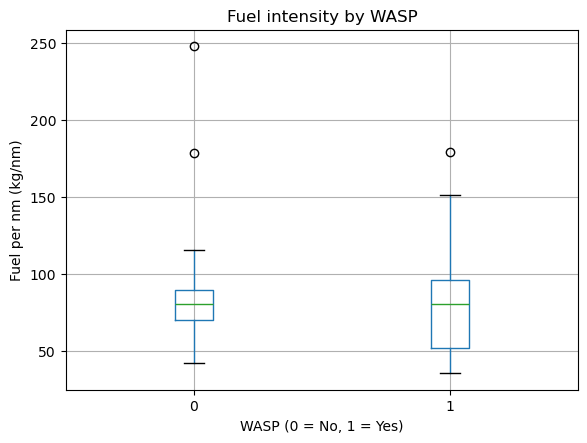

<Figure size 640x480 with 0 Axes>

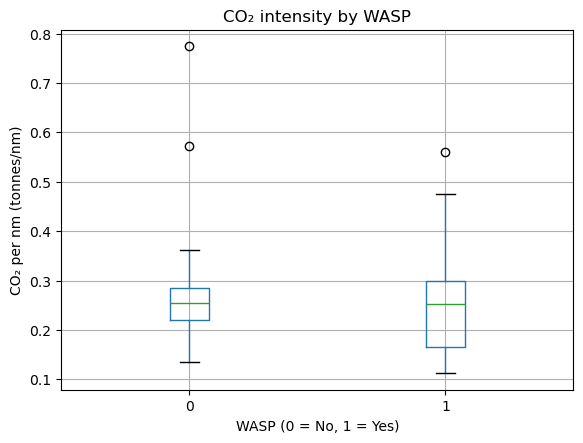

<Figure size 640x480 with 0 Axes>

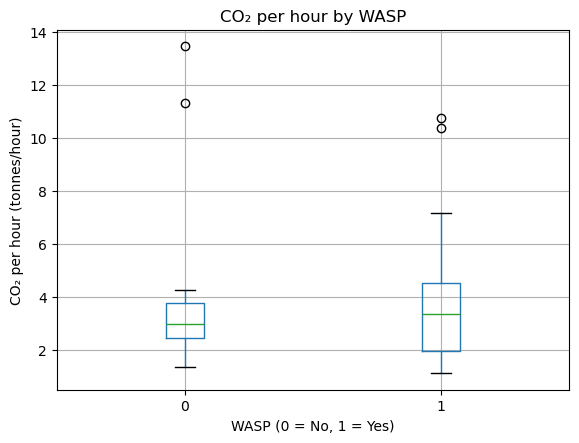

In [4]:
for col, ylabel, title in [
    ("fuel_per_nm", "Fuel per nm (kg/nm)", "Fuel intensity by WASP"),
    ("co2_per_nm", "CO₂ per nm (tonnes/nm)", "CO₂ intensity by WASP"),
    ("co2_per_hour", "CO₂ per hour (tonnes/hour)", "CO₂ per hour by WASP"),
]:
    plt.figure()
    df_eff.boxplot(column=col, by="wasp")
    plt.suptitle("")
    plt.title(title)
    plt.xlabel("WASP (0 = No, 1 = Yes)")
    plt.ylabel(ylabel)
    plt.show()


### Efficiency and intensity distributions by WASP status

This cell visualizes three efficiency-related metrics using boxplots to compare WASP and non-WASP ships:

1. **Fuel per nautical mile**  
   This metric reflects fuel efficiency per unit of distance. WASP ships exhibit a slightly lower median fuel intensity, but the distributions overlap substantially and show considerable variability. This indicates that while some WASP ships are more fuel-efficient, the effect is not consistent across the sample.

2. **CO₂ per nautical mile**  
   CO₂ per distance directly measures emissions efficiency. The median values for WASP and non-WASP ships are similar, with overlapping interquartile ranges. This suggests no clear or uniform reduction in emissions intensity associated with WASP across the dataset.

3. **CO₂ per hour**  
   CO₂ per hour captures operational emissions intensity. WASP ships show a slightly higher spread and similar median values compared to non-WASP ships, reflecting heterogeneous operating conditions rather than a systematic efficiency difference.

Overall, these plots show **directional but weak differences** between WASP and non-WASP ships. The substantial overlap and presence of outliers indicate that any efficiency effect of WASP is heterogeneous and not robustly distinguishable based on distributional comparisons alone.


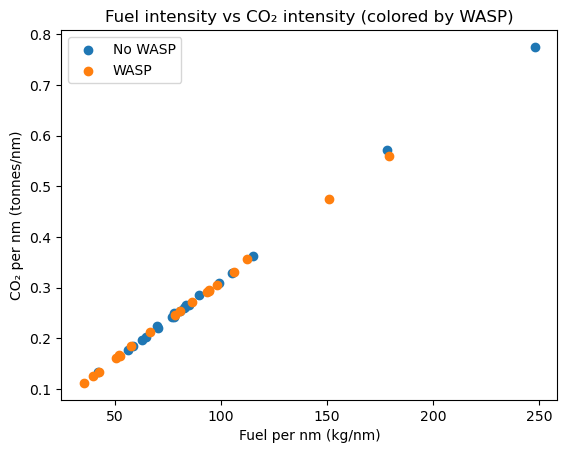

In [5]:
plt.figure()
m1 = df_eff["wasp"] == 1
plt.scatter(df_eff.loc[~m1, "fuel_per_nm"], df_eff.loc[~m1, "co2_per_nm"], label="No WASP")
plt.scatter(df_eff.loc[m1, "fuel_per_nm"], df_eff.loc[m1, "co2_per_nm"], label="WASP")
plt.title("Fuel intensity vs CO₂ intensity (colored by WASP)")
plt.xlabel("Fuel per nm (kg/nm)")
plt.ylabel("CO₂ per nm (tonnes/nm)")
plt.legend()
plt.show()


### Relationship between fuel intensity and CO₂ intensity

This scatter plot compares fuel consumption per nautical mile with CO₂ emissions per nautical mile, with points colored by WASP status.

The plot shows a strong linear relationship between fuel intensity and CO₂ intensity for both WASP and non-WASP ships, reflecting the direct link between fuel combustion and emissions.

WASP and non-WASP observations lie on the same overall relationship, indicating that WASP does not alter the emissions factor of fuel. Instead, any potential efficiency benefit would need to appear as systematically lower fuel-per-distance values, which is not clearly distinguishable from this plot alone.


In [6]:
def test_two_groups(df_in, col):
    a = df_in[df_in["wasp"] == 0][col].dropna()
    b = df_in[df_in["wasp"] == 1][col].dropna()

    t = stats.ttest_ind(a, b, equal_var=False)  # Welch
    mw = stats.mannwhitneyu(a, b, alternative="two-sided")

    out = {
        "metric": col,
        "n_no_wasp": len(a),
        "n_wasp": len(b),
        "mean_no_wasp": a.mean(),
        "mean_wasp": b.mean(),
        "diff_wasp_minus_no": b.mean() - a.mean(),
        "t_pvalue": t.pvalue,
        "mw_pvalue": mw.pvalue,
        "median_no_wasp": a.median(),
        "median_wasp": b.median(),
    }
    return out

tests = pd.DataFrame([
    test_two_groups(df_eff, "fuel_per_nm"),
    test_two_groups(df_eff, "co2_per_nm"),
    test_two_groups(df_eff, "co2_per_hour"),
])

tests


,metric,n_no_wasp,n_wasp,mean_no_wasp,mean_wasp,diff_wasp_minus_no,t_pvalue,mw_pvalue,median_no_wasp,median_wasp
0,fuel_per_nm,21,19,90.801429,82.674211,-8.127218,0.539665,0.724770,80.640000,80.740000
1,co2_per_nm,21,19,0.286319,0.259946,-0.026372,0.525206,0.664765,0.254385,0.253366
2,co2_per_hour,21,19,3.871780,3.856727,-0.015054,0.986949,0.892280,2.978141,3.353479


### Statistical tests comparing WASP and non-WASP ships

This table reports formal statistical comparisons between WASP and non-WASP ships for three efficiency-related metrics: fuel per nautical mile, CO₂ per nautical mile, and CO₂ per hour.

For each metric, two complementary tests are applied:
- **Welch’s t-test**, which compares group means while allowing for unequal variances
- **Mann–Whitney U test**, which compares medians and overall distribution shifts

Across all metrics, WASP ships exhibit slightly lower mean values, resulting in negative mean differences (WASP minus non-WASP). However, both t-test and Mann–Whitney p-values are well above conventional significance thresholds.

This indicates that while the direction of the differences is consistent with marginally better efficiency among WASP ships, the evidence is not statistically robust and may be driven by sample variability rather than a systematic effect.


In [17]:
g = (df_eff.groupby(["ship_type","wasp"])
     .agg(
         n=("imo","count"),
         mean_co2_per_nm=("co2_per_nm","mean"),
         mean_fuel_per_nm=("fuel_per_nm","mean"),
         mean_co2_per_hour=("co2_per_hour","mean"),
     )
     .reset_index())

has_both = g.groupby("ship_type")["wasp"].nunique()
both_types = has_both[has_both == 2].index.tolist()

g_both = g[g["ship_type"].isin(both_types)].copy()
g_both.sort_values(["ship_type","wasp"])


,ship_type,wasp,n,mean_co2_per_nm,mean_fuel_per_nm,mean_co2_per_hour
0,Bulk carrier,0,4,0.221579,70.237500,2.440841
1,Bulk carrier,1,2,0.258562,82.460000,2.479206
2,Chemical tanker,0,1,0.266383,84.860000,3.433569
3,Chemical tanker,1,1,0.164472,52.440000,1.851191
4,General cargo ship,0,1,0.265316,83.630000,2.978141
5,General cargo ship,1,1,0.124975,39.840000,1.283180
6,Other ship types,0,5,0.204331,64.632000,2.380697
7,Other ship types,1,5,0.220147,69.338000,4.274124
8,Ro-pax ship,0,3,0.569597,180.553333,9.519938
9,Ro-pax ship,1,3,0.381894,122.293333,6.021555


### Efficiency comparisons within ship types

This table reports average efficiency metrics by ship type and WASP status, restricted to ship types that contain **both** WASP and non-WASP observations. This ensures that comparisons are made within comparable vessel classes rather than across fundamentally different ship types.

For each ship type, the table shows:
- the number of observations (`n`)
- mean CO₂ emissions per nautical mile
- mean fuel consumption per nautical mile
- mean CO₂ emissions per hour

The results indicate that efficiency differences vary substantially by ship type. In some cases (e.g. Ro-pax ships and Chemical tankers), WASP-equipped ships show noticeably lower fuel and CO₂ intensity. In other ship types (e.g. Bulk carriers and Ro-ro ships), differences are small or reversed.

Sample sizes within ship types are often very small, which limits statistical reliability. Overall, this table suggests that any efficiency effects of WASP are **heterogeneous and ship-type dependent**, rather than consistent across the entire fleet.


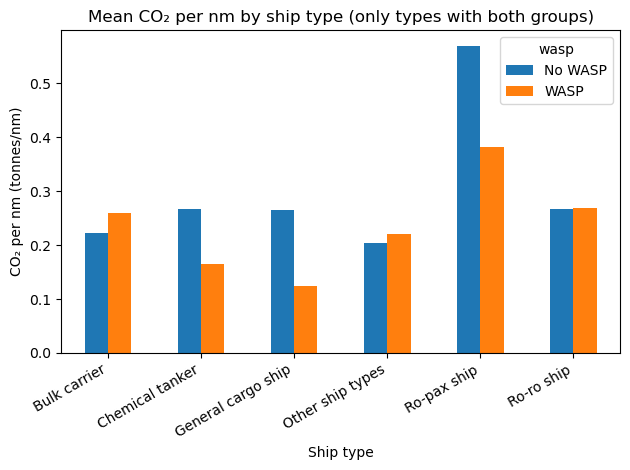

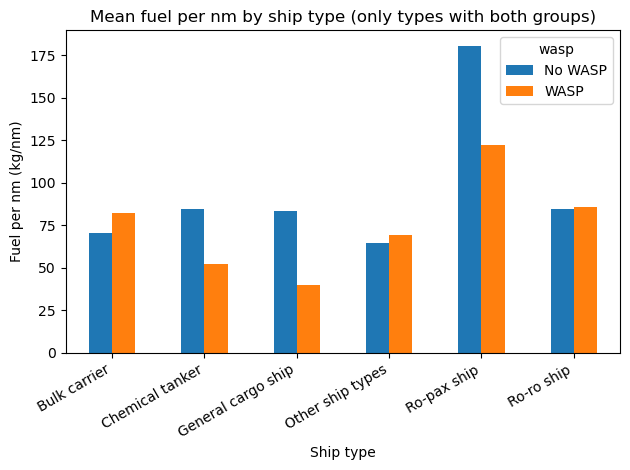

In [8]:
# CO2_per_nm by ship type
p1 = g_both.pivot(index="ship_type", columns="wasp", values="mean_co2_per_nm").rename(columns={0:"No WASP",1:"WASP"})
p1.plot(kind="bar")
plt.title("Mean CO₂ per nm by ship type (only types with both groups)")
plt.xlabel("Ship type")
plt.ylabel("CO₂ per nm (tonnes/nm)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# fuel_per_nm by ship type
p2 = g_both.pivot(index="ship_type", columns="wasp", values="mean_fuel_per_nm").rename(columns={0:"No WASP",1:"WASP"})
p2.plot(kind="bar")
plt.title("Mean fuel per nm by ship type (only types with both groups)")
plt.xlabel("Ship type")
plt.ylabel("Fuel per nm (kg/nm)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Mean efficiency by ship type and WASP status

These bar charts compare average CO₂ emissions per nautical mile and fuel consumption per nautical mile across ship types, restricted to ship types that include both WASP and non-WASP observations.

The CO₂-per-distance chart shows that for some ship types—most notably Ro-pax ships and General cargo ships—WASP-equipped vessels exhibit substantially lower emissions intensity. In other ship types, such as Bulk carriers and Ro-ro ships, differences between WASP and non-WASP ships are small or reversed.

The fuel-per-distance chart mirrors this pattern, indicating that reductions in CO₂ intensity are driven by lower fuel intensity rather than changes in emissions factors. However, sample sizes within ship types are small, and these averages are sensitive to individual observations.

Overall, these plots suggest that any efficiency benefits of WASP are **ship-type dependent** and not consistent across the entire fleet.


In [9]:
# Ship-type fixed effects via C(ship_type)
m_co2nm = smf.ols(
    "co2_per_nm ~ wasp + hours + DWT + GT + length + C(ship_type)",
    data=df_eff
).fit(cov_type="HC3")

m_co2nm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             co2_per_nm   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     3.496
Date:                Thu, 08 Jan 2026   Prob (F-statistic):            0.00402
Time:                        21:45:23   Log-Likelihood:                 54.023
No. Observations:                  40   AIC:                            -86.05
Df Residuals:                      29   BIC:                            -67.47
Df Model:                          10                                         
Covariance Type:                  HC3                                         
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              0.1357      0.267      0.508      0.611      -0.388       0.659
C(ship_type)[T.Chemical tanker]        0.0477      0.053      0.904      0.366      -0.056       0.151
C(ship_type)[T.General cargo ship]     0.0268      0.056      0.479      0.632      -0.083       0.137
C(ship_type)[T.Other ship types]       0.0679      0.068      1.003      0.316      -0.065       0.201
C(ship_type)[T.Ro-pax ship]            0.2220      0.176      1.262      0.207      -0.123       0.567
C(ship_type)[T.Ro-ro ship]             0.0941      0.101      0.931      0.352      -0.104       0.292
wasp                                  -0.0323      0.043     -0.754      0.451      -0.116       0.052
hours                              -1.408e-05   1.29e-05     -1.091      0.275   -3.94e-05    1.12e-05
DWT                                -1.676e-06   2.93e-06     -0.572      0.567   -7.42e-06    4.06e-06
GT                                  5.514e-06   4.38e-06      1.260      0.208   -3.06e-06    1.41e-05
length                                 0.0003      0.002      0.124      0.902      -0.004       0.005
==============================================================================
Omnibus:                        0.779   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.677   Jarque-Bera (JB):                0.548
Skew:                           0.283   Prob(JB):                        0.760
Kurtosis:                       2.912   Cond. No.                     4.65e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 4.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Regression analysis: CO₂ emissions per nautical mile with ship-type fixed effects

This regression estimates the association between WASP and CO₂ emissions per nautical mile while controlling for operational intensity (hours), ship size (DWT, GT, length), and ship-type fixed effects.

The WASP coefficient is negative, indicating that WASP-equipped ships tend to emit slightly less CO₂ per nautical mile when comparing ships within the same ship type and holding other factors constant. However, the effect is not statistically significant, and the confidence interval includes zero.

The model explains a substantial share of the variation in CO₂ intensity (R² ≈ 0.76), suggesting that ship characteristics and ship type are important determinants of emissions intensity. Robust (HC3) standard errors are used to account for heteroskedasticity.

Overall, this specification provides no statistically robust evidence that WASP systems systematically reduce CO₂ emissions per distance traveled, though the estimated effect is directionally consistent with a modest efficiency improvement.


In [10]:
m_fuelnm = smf.ols(
    "fuel_per_nm ~ wasp + hours + DWT + GT + length + C(ship_type)",
    data=df_eff
).fit(cov_type="HC3")

m_fuelnm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fuel_per_nm   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     3.413
Date:                Thu, 08 Jan 2026   Prob (F-statistic):            0.00467
Time:                        21:45:30   Log-Likelihood:                -176.27
No. Observations:                  40   AIC:                             374.5
Df Residuals:                      29   BIC:                             393.1
Df Model:                          10                                         
Covariance Type:                  HC3                                         
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             40.7838     82.344      0.495      0.620    -120.607     202.174
C(ship_type)[T.Chemical tanker]       15.3394     15.993      0.959      0.337     -16.006      46.685
C(ship_type)[T.General cargo ship]     8.4351     17.764      0.475      0.635     -26.383      43.253
C(ship_type)[T.Other ship types]      21.4083     20.818      1.028      0.304     -19.395      62.211
C(ship_type)[T.Ro-pax ship]           69.8852     53.884      1.297      0.195     -35.725     175.495
C(ship_type)[T.Ro-ro ship]            29.1881     30.932      0.944      0.345     -31.437      89.813
wasp                                  -9.9253     13.318     -0.745      0.456     -36.028      16.177
hours                                 -0.0043      0.004     -1.064      0.287      -0.012       0.004
DWT                                   -0.0005      0.001     -0.603      0.546      -0.002       0.001
GT                                     0.0018      0.001      1.234      0.217      -0.001       0.005
length                                 0.1008      0.694      0.145      0.885      -1.259       1.461
==============================================================================
Omnibus:                        0.513   Durbin-Watson:                   2.021
Prob(Omnibus):                  0.774   Jarque-Bera (JB):                0.493
Skew:                           0.245   Prob(JB):                        0.781
Kurtosis:                       2.763   Cond. No.                     4.65e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 4.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Regression analysis: fuel consumption per nautical mile with ship-type fixed effects

This regression estimates the association between WASP and fuel consumption per nautical mile while controlling for operational intensity (hours), ship size (DWT, GT, length), and ship-type fixed effects.

The WASP coefficient is negative, indicating that WASP-equipped ships tend to use less fuel per nautical mile compared to non-WASP ships of the same ship type, holding other characteristics constant. However, the effect is not statistically significant, and the confidence interval includes zero.

The model explains a substantial share of the variation in fuel intensity (R² ≈ 0.77), highlighting the importance of ship characteristics and ship type in determining fuel efficiency. Robust (HC3) standard errors are used to account for heteroskedasticity.

Overall, while the estimated effect of WASP on fuel intensity is directionally consistent with improved efficiency, the evidence is not statistically robust in this sample.


In [11]:
def wasp_effect(model, name="wasp"):
    ci = model.conf_int().loc[name]
    return pd.Series({
        "coef": model.params[name],
        "p_value": model.pvalues[name],
        "ci_low": ci[0],
        "ci_high": ci[1],
        "n": int(model.nobs),
        "r2": model.rsquared,
    })

effects = pd.DataFrame({
    "CO2_per_nm": wasp_effect(m_co2nm),
    "Fuel_per_nm": wasp_effect(m_fuelnm),
}).T

effects


,coef,p_value,ci_low,ci_high,n,r2
CO2_per_nm,-0.032338,0.450567,-0.116347,0.051670,40.0,0.762020
Fuel_per_nm,-9.925306,0.456116,-36.027986,16.177375,40.0,0.765813


### Summary of estimated WASP effects on efficiency metrics

This table summarizes the estimated effect of WASP from the two ship-type fixed-effects regressions, focusing specifically on the WASP coefficient, its statistical significance, and confidence interval.

For both CO₂ emissions per nautical mile and fuel consumption per nautical mile, the estimated WASP coefficients are negative, indicating directionally lower emissions and fuel intensity for WASP-equipped ships. However, in both cases the p-values are well above conventional significance thresholds and the confidence intervals include zero.

The models explain a substantial share of the variation in efficiency metrics (R² ≈ 0.76), but the uncertainty around the WASP estimates indicates that the data do not support a statistically robust efficiency effect.

Overall, this summary confirms that while the estimated effects of WASP are consistent with modest efficiency improvements, the evidence remains inconclusive given the sample size and variability in the data.


In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

features = ["DWT","GT","length","hours"]

wasp = df_eff[df_eff["wasp"] == 1].copy()
non = df_eff[df_eff["wasp"] == 0].copy()

# Standardize features for fair distance
scaler = StandardScaler()
X_non = scaler.fit_transform(non[features])
X_wasp = scaler.transform(wasp[features])

nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_non)
dist, idx = nn.kneighbors(X_wasp)

matched_non = non.iloc[idx.flatten()].reset_index(drop=True)
matched_wasp = wasp.reset_index(drop=True)

pairs = pd.DataFrame({
    "wasp_imo": matched_wasp["imo"],
    "non_imo": matched_non["imo"],
    "co2_per_nm_wasp": matched_wasp["co2_per_nm"],
    "co2_per_nm_non": matched_non["co2_per_nm"],
    "fuel_per_nm_wasp": matched_wasp["fuel_per_nm"],
    "fuel_per_nm_non": matched_non["fuel_per_nm"],
    "distance_feature_space": dist.flatten(),
})

pairs["diff_co2_per_nm"] = pairs["co2_per_nm_wasp"] - pairs["co2_per_nm_non"]
pairs["diff_fuel_per_nm"] = pairs["fuel_per_nm_wasp"] - pairs["fuel_per_nm_non"]

pairs.head()


,wasp_imo,non_imo,co2_per_nm_wasp,co2_per_nm_non,fuel_per_nm_wasp,fuel_per_nm_non,distance_feature_space,diff_co2_per_nm,diff_fuel_per_nm
0,9512331,9144354,0.272051,0.265316,86.54,83.63,2.769719,0.006735,2.91
1,9798856,9144354,0.245073,0.265316,78.38,83.63,2.734354,-0.020243,-5.25
2,9743758,9147681,0.164472,0.258809,52.44,82.66,0.697688,-0.094337,-30.22
3,9631345,9153642,0.124975,0.201731,39.84,64.47,0.816324,-0.076756,-24.63
4,7633375,7724265,0.212686,0.223586,66.34,69.74,0.735226,-0.010900,-3.40


### Matched comparison of similar WASP and non-WASP ships

This analysis applies nearest-neighbor matching to compare WASP-equipped ships with the most similar non-WASP ships based on ship size and operational characteristics (DWT, GT, length, and hours).

All matching variables are standardized to ensure that distances in feature space reflect relative similarity rather than scale differences. Each WASP observation is matched to the closest non-WASP observation, creating paired comparisons between otherwise comparable ships.

The resulting table reports emissions and fuel intensity for each matched pair, along with the difference between WASP and non-WASP ships (WASP minus non-WASP). Negative differences indicate lower intensity for the WASP-equipped ship.

The matched differences vary in both magnitude and direction, suggesting that while some WASP ships outperform their closest non-WASP counterparts, others do not. This reinforces the conclusion that any efficiency effects of WASP are heterogeneous and not consistently observable even among closely comparable vessels.


In [13]:
print("Matched pairs:", len(pairs))

print("\nMean diff (WASP - non) CO2_per_nm:", pairs["diff_co2_per_nm"].mean())
print("Mean diff (WASP - non) fuel_per_nm:", pairs["diff_fuel_per_nm"].mean())

# Paired tests
t1 = stats.ttest_rel(pairs["co2_per_nm_wasp"], pairs["co2_per_nm_non"], nan_policy="omit")
t2 = stats.ttest_rel(pairs["fuel_per_nm_wasp"], pairs["fuel_per_nm_non"], nan_policy="omit")

print("\nPaired t-test CO2_per_nm p-value:", t1.pvalue)
print("Paired t-test fuel_per_nm p-value:", t2.pvalue)


Matched pairs: 19

Mean diff (WASP - non) CO2_per_nm: -0.03939255824658297
Mean diff (WASP - non) fuel_per_nm: -12.447368421052634

Paired t-test CO2_per_nm p-value: 0.2238288116822373
Paired t-test fuel_per_nm p-value: 0.22715186416667568


### Summary of matched-pair differences and paired tests

This output summarizes the results of the nearest-neighbor matched comparison between WASP and non-WASP ships.

A total of 19 matched pairs are analyzed. On average, WASP ships exhibit lower CO₂ emissions per nautical mile and lower fuel consumption per nautical mile compared to their matched non-WASP counterparts, as indicated by the negative mean differences.

However, paired t-tests for both CO₂ per nautical mile and fuel per nautical mile yield p-values well above conventional significance thresholds. This indicates that, even among closely matched ships, the observed differences are not statistically robust.

These results reinforce earlier findings: while WASP ships show directionally lower emissions and fuel intensity on average, the evidence remains inconclusive given the variability and limited sample size.


### Overall conclusion

Across multiple analytical approaches—including efficiency metrics, distributional comparisons, statistical tests, ship-type comparisons, fixed-effects regressions, and matched-pair analysis—WASP-equipped ships show a weak and consistent tendency toward lower fuel and CO₂ intensity.

However, these differences are small, heterogeneous across ship types, and not statistically significant in this sample. As a result, the analysis does not provide strong or conclusive evidence that WASP systems systematically improve operational efficiency, although the direction of the estimates is consistent with potential efficiency benefits.

Overall, the findings suggest that any efficiency effects of WASP are context-dependent and difficult to detect with the available data.
